Import Libraries

In [1]:
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
from scipy.stats import linregress

1. Define Data Directory and Read Data 

In [2]:
data_dir = '/Users/anastringer_1/Desktop/Breakup_Timing_Data/'
csv_files = glob.glob(os.path.join(data_dir, '*_data.csv'))

print("CSV files being read:")
for file in csv_files:
    print(file)

#reading and combining all the data 
df_list = []
for file in csv_files:
    df = pd.read_csv(file)
    filename = os.path.basename(file)
    community_name = filename.replace('_data.csv', '').strip().title()
    df['Community'] = community_name
    df_list.append(df)

#combing all data frames into one big one
ice_data = pd.concat(df_list, ignore_index=True)

CSV files being read:
/Users/anastringer_1/Desktop/Breakup_Timing_Data/Nunam Iqua_data.csv
/Users/anastringer_1/Desktop/Breakup_Timing_Data/Stebbins_data.csv
/Users/anastringer_1/Desktop/Breakup_Timing_Data/Hooper Bay_data.csv
/Users/anastringer_1/Desktop/Breakup_Timing_Data/Mekoryuk_data.csv
/Users/anastringer_1/Desktop/Breakup_Timing_Data/Utqiagvik_data.csv
/Users/anastringer_1/Desktop/Breakup_Timing_Data/Gambell_data.csv
/Users/anastringer_1/Desktop/Breakup_Timing_Data/Kotzebue_data.csv
/Users/anastringer_1/Desktop/Breakup_Timing_Data/Nuiqsut_data.csv
/Users/anastringer_1/Desktop/Breakup_Timing_Data/Elim_data.csv
/Users/anastringer_1/Desktop/Breakup_Timing_Data/Toksook Bay_data.csv
/Users/anastringer_1/Desktop/Breakup_Timing_Data/Shaktoolik_data.csv
/Users/anastringer_1/Desktop/Breakup_Timing_Data/Teller_data.csv
/Users/anastringer_1/Desktop/Breakup_Timing_Data/Savoonga_data.csv
/Users/anastringer_1/Desktop/Breakup_Timing_Data/Kwigillingok_data.csv
/Users/anastringer_1/Desktop/Break

2. Checking that'Year' column is numeric and correctly formatted

In [3]:
ice_data['Year'] = pd.to_numeric(ice_data['Year'], errors='coerce')
ice_data = ice_data.dropna(subset=['Year'])
ice_data['Year'] = ice_data['Year'].astype(int)

print("\nUnique years after loading data:")
print(sorted(ice_data['Year'].unique()))


Unique years after loading data:
[2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]


3. Renaming columns for consistency 

In [4]:
print("\nColumns before renaming:")
print(ice_data.columns)
ice_data.rename(columns={
    'Breakup Date (DOY)': 'Breakup_DOY',
    'Breakup Date (doy)': 'Breakup_DOY',
    'SLIE Distance (km)': 'SLIE',
    'Breakup Uncertainty (days)': 'Breakup_Uncertainty'
}, inplace=True)

#checking columns
required_columns = ['Year', 'Breakup_DOY', 'SLIE', 'Community']
missing_columns = [col for col in required_columns if col not in ice_data.columns]
if missing_columns:
    print(f"\nMissing columns in ice_data: {missing_columns}")
else:
    print("\nAll required columns are present after renaming.")

#confirming
print("\nColumns after renaming:")
print(ice_data.columns)


Columns before renaming:
Index(['Year', 'SLIE Distance (km)', 'Breakup Date (DOY)',
       'Breakup Uncertainty (days)', 'Community'],
      dtype='object')

All required columns are present after renaming.

Columns after renaming:
Index(['Year', 'SLIE', 'Breakup_DOY', 'Breakup_Uncertainty', 'Community'], dtype='object')


4. converting 'Breakup_DOY' and 'SLIE' to numeric

In [5]:
ice_data['Breakup_DOY'] = pd.to_numeric(ice_data['Breakup_DOY'], errors='coerce')
ice_data['SLIE'] = pd.to_numeric(ice_data['SLIE'], errors='coerce')

5. removing rows with NaN in 'Breakup_DOY' or 'SLIE' 

In [6]:
initial_count = ice_data.shape[0]
ice_data = ice_data.dropna(subset=['Breakup_DOY', 'SLIE'])
final_count = ice_data.shape[0]
print(f"\nRemoved {initial_count - final_count} rows with missing 'Breakup_DOY' or 'SLIE'.")

#removing outliers where breakup DOY = 0
outliers = ice_data[ice_data['Breakup_DOY'] <= 0]
if not outliers.empty:
    print("\nOutliers found in 'Breakup_DOY':")
    print(outliers[['Year', 'Community', 'Breakup_DOY']])
    ice_data = ice_data[ice_data['Breakup_DOY'] > 0]
    print(f"Removed {outliers.shape[0]} outlier rows where 'Breakup_DOY' <= 0.")
else:
    print("\nNo outliers found in 'Breakup_DOY'.")


Removed 7 rows with missing 'Breakup_DOY' or 'SLIE'.

Outliers found in 'Breakup_DOY':
     Year   Community  Breakup_DOY
116  2001     Gambell          0.0
118  2003     Gambell          0.0
133  2018     Gambell          0.0
134  2019     Gambell          0.0
294  2018    Savoonga          0.0
295  2019    Savoonga          0.0
547  2018  Shishmaref          0.0
548  2019  Shishmaref          0.0
550  2021  Shishmaref          0.0
Removed 9 outlier rows where 'Breakup_DOY' <= 0.


6. Assigning communities to regions 

In [7]:
northern_communities = [
    'Utqiagvik', 'Wainwright', 'Point Lay', 'Point Hope', 'Kivalina', 
    'Kotzebue', 'Shishmaref', 'Wales', 'Deering', 'Kaktovik', 
    'Prudhoe Bay', 'Nuiqsut'
]
southern_communities = [
    'Kotlik', 'Emmonak', 'Alakanuk', 'Nunam Iqua', 'Stebbins', 
    'Koyuk', 'Golovin', 'Elim', 'Nome', 'Brevig Mission', 
    'Teller', 'Shaktoolik', 'Unalakleet', 'Hooper Bay', 
    'Quinhagak', 'Kipnuk', 'Chefornak', 'Newtok', 'Tununak', 
    'Toksook Bay', 'Nightmute', 'Kwigillingok', 'Kongiganak', 
    'Scammon Bay', 'Mekoryuk', 'Gambell', 'Savoonga'
]

ice_data['Community'] = ice_data['Community'].str.strip().str.title()

def assign_region(community):
    if community in northern_communities:
        return 'Northern'
    elif community in southern_communities:
        return 'Southern'
    else:
        raise ValueError(f"Community '{community}' not found in any region list.")

ice_data['Region'] = ice_data['Community'].apply(assign_region)

7. Calculating mean values from communities

In [8]:
community_means = ice_data.groupby('Community').agg({
    'Breakup_DOY': 'mean',
    'SLIE': 'mean'
}).reset_index()

community_means.rename(columns={
    'Breakup_DOY': 'Mean_Breakup_DOY',
    'SLIE': 'Mean_SLIE'
}, inplace=True)

ice_data = pd.merge(ice_data, community_means, on='Community', how='left')

8. Calculate anamolies 

In [9]:
#breakup doy
ice_data['Breakup_Anomaly'] = ice_data['Breakup_DOY'] - ice_data['Mean_Breakup_DOY']

#slie
ice_data['SLIE_Anomaly'] = ice_data['SLIE'] - ice_data['Mean_SLIE']

9. aggregating data by region, year

In [10]:
region_year_data = ice_data.groupby(['Region', 'Year']).agg({
    'Breakup_Anomaly': 'mean',
    'SLIE_Anomaly': 'mean'
}).reset_index()

10. performing trend analysis

In [11]:
#northern 
northern_data = region_year_data[region_year_data['Region'] == 'Northern']
if not northern_data.empty:
    slope, intercept, r_value, p_value, std_err = linregress(
        northern_data['Year'], northern_data['Breakup_Anomaly'])
    print(f"\nNorthern Region Breakup Anomaly Trend: slope={slope:.4f}, p-value={p_value:.4f}")
else:
    print("\nNo data available for the Northern Region.")

#southern
southern_data = region_year_data[region_year_data['Region'] == 'Southern']
if not southern_data.empty:
    slope, intercept, r_value, p_value, std_err = linregress(
        southern_data['Year'], southern_data['Breakup_Anomaly'])
    print(f"Southern Region Breakup Anomaly Trend: slope={slope:.4f}, p-value={p_value:.4f}")
else:
    print("No data available for the Southern Region.")


Northern Region Breakup Anomaly Trend: slope=-0.7476, p-value=0.0049
Southern Region Breakup Anomaly Trend: slope=-0.6864, p-value=0.0320


11. quick visualizations of data for fun

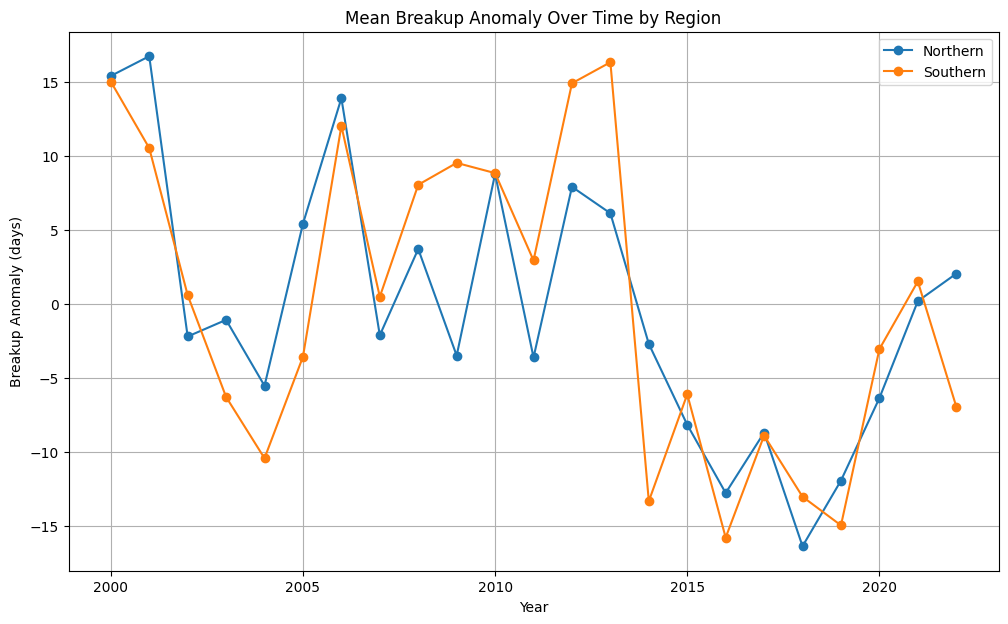

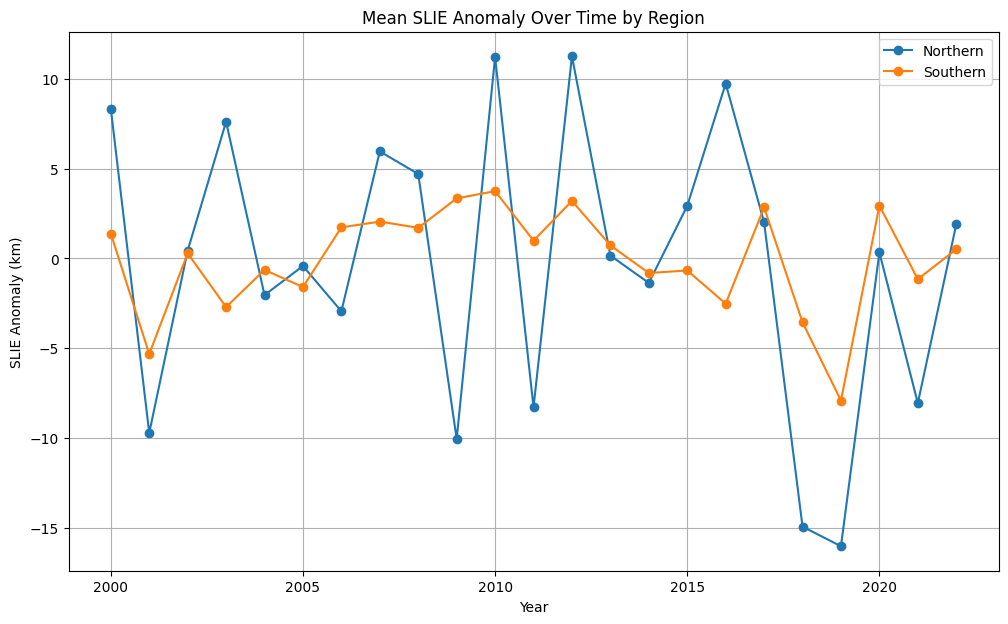

In [12]:
# a) breakup anamolies overtime 
plt.figure(figsize=(12,7))
for region in region_year_data['Region'].unique():
    data = region_year_data[region_year_data['Region'] == region]
    plt.plot(data['Year'], data['Breakup_Anomaly'], label=region, marker='o')
plt.title('Mean Breakup Anomaly Over Time by Region')
plt.xlabel('Year')
plt.ylabel('Breakup Anomaly (days)')
plt.legend()
plt.grid(True)
plt.show()

# b) SLIE anamolies over time 
plt.figure(figsize=(12,7))
for region in region_year_data['Region'].unique():
    data = region_year_data[region_year_data['Region'] == region]
    plt.plot(data['Year'], data['SLIE_Anomaly'], label=region, marker='o')
plt.title('Mean SLIE Anomaly Over Time by Region')
plt.xlabel('Year')
plt.ylabel('SLIE Anomaly (km)')
plt.legend()
plt.grid(True)
plt.show()

12. Exporting ice_data into a .csv

In [13]:
ice_data.to_csv('ice_data4.csv', index=False)
print("\nice_data has been exported to 'ice_data.csv'")


ice_data has been exported to 'ice_data.csv'


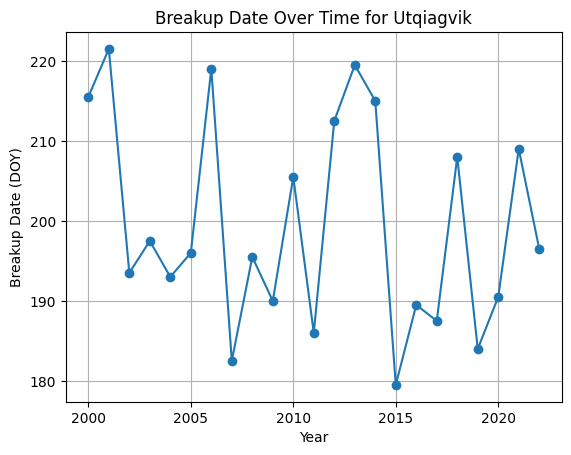

In [15]:
#another plot for fun 
community_data = ice_data[ice_data['Community'] == 'Utqiagvik']
plt.plot(community_data['Year'], community_data['Breakup_DOY'], marker='o')
plt.title('Breakup Date Over Time for Utqiagvik')
plt.xlabel('Year')
plt.ylabel('Breakup Date (DOY)')
plt.grid(True)
plt.show()